## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load the Dataset

In [2]:
fev_source = 'https://raw.githubusercontent.com/GTPB/PSLS20/master/data/fev.txt'

fev = pd.read_csv(fev_source, sep = '\t')

fev.head()

,age,fev,height,gender,smoking
0,9,1.708,57.0,f,0
1,8,1.724,67.5,f,0
2,7,1.720,54.5,f,0
3,9,1.558,53.0,m,0
4,9,1.895,57.0,m,0


## 3. Data Cleaning & Encoding

In [3]:
fev['gender'] = fev['gender'].map({'f': 0, 'm': 1})  # if sex is stored as 'f'/'m'
fev['smoking'] = fev['smoking'].astype(int)         # ensure smoker is numeric

In [4]:
fev.head()

,age,fev,height,gender,smoking
0,9,1.708,57.0,0,0
1,8,1.724,67.5,0,0
2,7,1.720,54.5,0,0
3,9,1.558,53.0,1,0
4,9,1.895,57.0,1,0


## 4. Explore the dataset

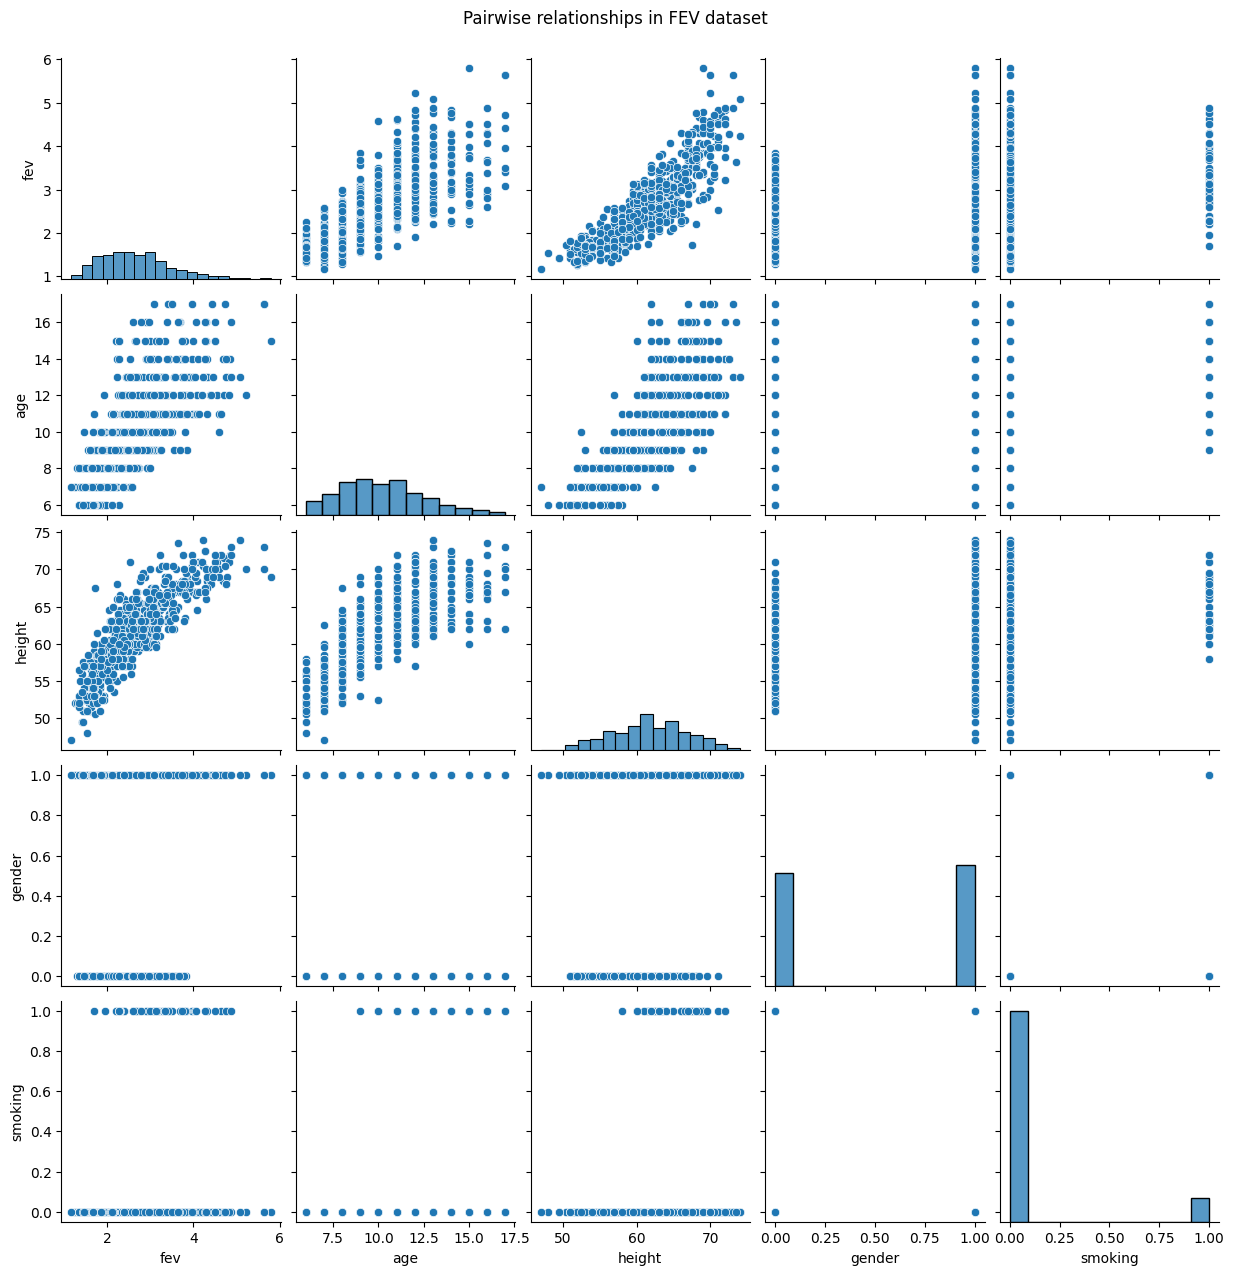

In [5]:

sns.pairplot(fev[['fev','age','height','gender','smoking']])
plt.suptitle("Pairwise relationships in FEV dataset", y=1.02)
plt.show()

## 5. Split Train/Test

In [6]:
X = fev[['age', 'height', 'gender', 'smoking']]
y = fev['fev']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
X_train.head()

,age,height,gender,smoking
564,11,65.0,0,1
605,15,66.5,0,0
485,11,67.5,1,0
441,12,64.5,0,0
305,11,61.5,0,0


## 6: Train the Multivariate Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Inspect the model coefficients

In [10]:
print("Intercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept: -4.601236676113932
age: 0.08695350247792027
height: 0.10294535986715453
gender: 0.14827068216247605
smoking: -0.17458423567225576


Interpretation biologically:
 - Each coefficient tells how much FEV changes per unit change in that predictor, adjusting for others.

Example: A positive height coefficient means taller children tend to have higher FEV when age, sex, and smoking are held constant.

## Evaluate the model

In [11]:
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.7821789359644236
Mean Squared Error: 0.1576525280675643


## Challenge

Try removing gender, smoking and both to see the effect on FEV